# TAHAP AWAL
LIBRARY
PREPROCESSING
AFC PAFC





In [21]:
# ===============================
# Library utama
# ===============================
import numpy as np
import pandas as pd

# ===============================
# Visualisasi
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Statistik time series
# ===============================
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ===============================
# Machine Learning (AMBP)
# ===============================
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ===============================
# Setting tampilan
# ===============================
plt.style.use('default')
sns.set_theme()

In [22]:
# ===============================
# Load dataset
# ===============================
df = pd.read_excel("CHNTBFIX.xlsx")

# Hapus kolom Unnamed
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df.tail()

,DATE,RAINFALL_MM
535,2025-08-01,11.26
536,2025-09-01,52.30
537,2025-10-01,76.20
538,2025-11-01,199.84
539,2025-12-01,246.83


In [23]:
# Ubah kolom DATE menjadi datetime
df['DATE'] = pd.to_datetime(df['DATE'])

# Urutkan berdasarkan tanggal
df = df.sort_values('DATE')

# Set DATE sebagai index
rain_series = df.set_index('DATE')['RAINFALL_MM']

# Paksa frekuensi bulanan awal bulan
rain_series = rain_series.asfreq('MS')

rain_series.head()

,RAINFALL_MM
DATE,
1981-01-01,370.93
1981-02-01,326.56
1981-03-01,219.61
1981-04-01,116.93
1981-05-01,127.20


In [24]:
print("Shape data:", rain_series.shape)
print("Tipe index:", type(rain_series.index))
print("Frekuensi:", rain_series.index.freq)
print("Periode data:",
      rain_series.index.min(),
      "sampai",
      rain_series.index.max())

Shape data: (540,)
Tipe index: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Frekuensi: <MonthBegin>
Periode data: 1981-01-01 00:00:00 sampai 2025-12-01 00:00:00


In [25]:
print("Jumlah missing value:", rain_series.isna().sum())
print("Jumlah nilai negatif:", (rain_series < 0).sum())
rain_series.describe()

Jumlah missing value: 0
Jumlah nilai negatif: 0


,RAINFALL_MM
count,540.000000
mean,108.293778
std,107.291980
min,0.180000
25%,9.387500
50%,80.570000
75%,181.645000
max,428.500000


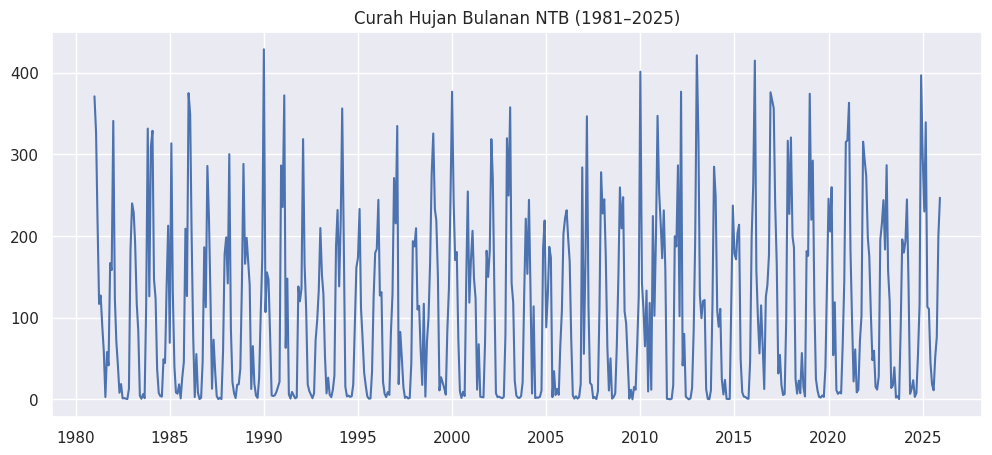

In [26]:
plt.figure(figsize=(12,5))
plt.plot(rain_series)
plt.title("Curah Hujan Bulanan NTB (1981–2025)")
plt.show()

In [27]:
adf_result = adfuller(rain_series)

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])

ADF Statistic : -5.671213078228454
p-value       : 8.913329967612267e-07


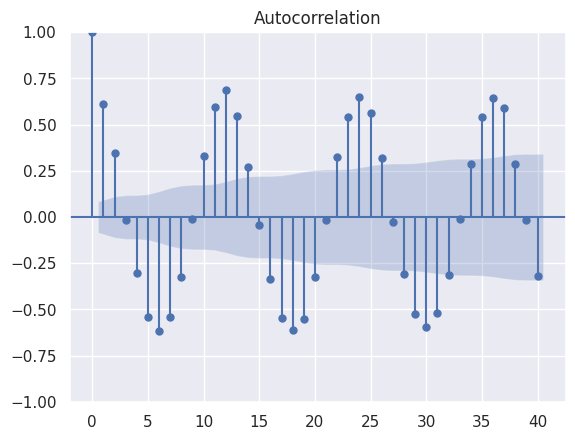

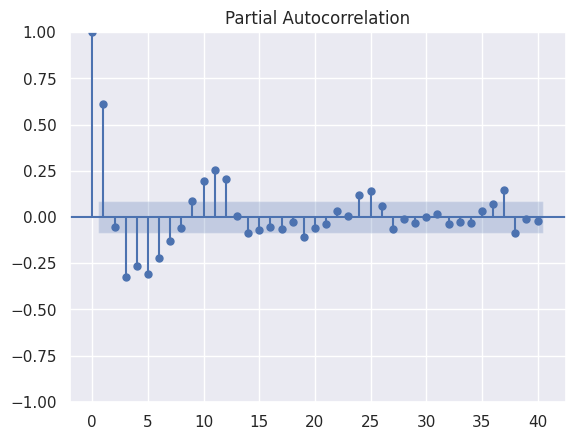

In [28]:
plot_acf(rain_series, lags=40)
plt.show()

plot_pacf(rain_series, lags=40)
plt.show()

In [29]:
# ===============================
# Definisi block-based forecasting
# ===============================
blocks = [
    ('1981-01-01','1990-12-01','1991-01-01','1991-12-01'),
    ('1986-01-01','1995-12-01','1996-01-01','1996-12-01'),
    ('1991-01-01','2000-12-01','2001-01-01','2001-12-01'),
    ('1996-01-01','2005-12-01','2006-01-01','2006-12-01'),
    ('2001-01-01','2010-12-01','2011-01-01','2011-12-01'),
    ('2006-01-01','2015-12-01','2016-01-01','2016-12-01'),
    ('2011-01-01','2020-12-01','2021-01-01','2021-12-01'),
    ('2016-01-01','2025-12-01','2026-01-01','2026-12-01')
]

# SARIMA

# BLOK 1

In [30]:
sarima_results = []

Jumlah data training: (120,)
Jumlah data aktual 1991: (12,)

Training selesai

=== ERROR TRAINING BLOK 1 ===
MAE  : 59.499823442443436
MSE  : 7952.562036620108
RMSE : 89.17713853124077
MAPE : 533.7277571704188
R2   : 0.3115877125062875

=== HASIL PREDIKSI 12 BULAN (1991) ===
            PREDIKSI_1991
DATE                     
1991-01-01     254.144065
1991-02-01     222.488457
1991-03-01     171.731915
1991-04-01      90.386804
1991-05-01      45.602122
1991-06-01      29.650307
1991-07-01      12.119760
1991-08-01       4.465969
1991-09-01      17.054095
1991-10-01      37.276451
1991-11-01     137.103766
1991-12-01     184.527971

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_1991  PREDIKSI_1991
DATE                                  
1991-01-01       235.49     254.144065
1991-02-01       372.08     222.488457
1991-03-01        63.19     171.731915
1991-04-01       147.90      90.386804
1991-05-01         6.26      45.602122
1991-06-01         1.11      29.650307
1991-07

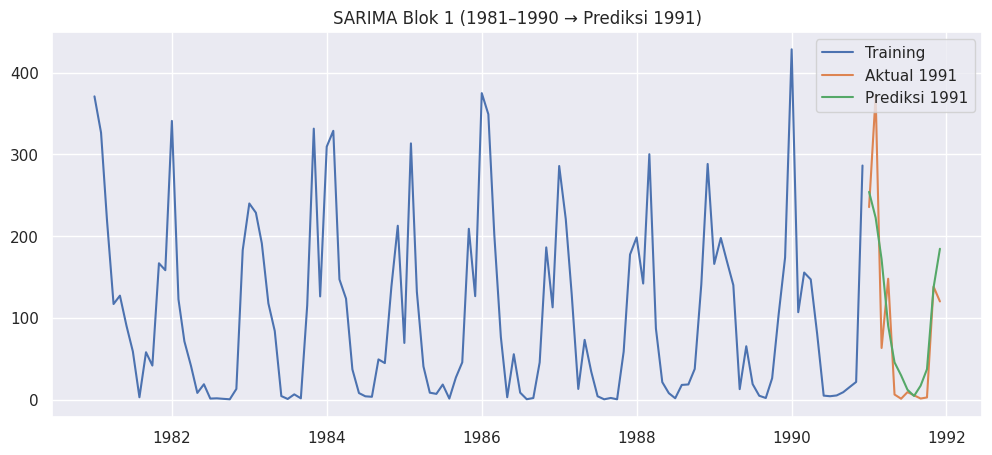

In [31]:
# ===============================
# SARIMA BLOK 1 (FULL 1 CELL)
# ===============================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# DATA TRAINING & AKTUAL
# ===============================
train_block1 = rain_series.loc['1981-01-01':'1990-12-01']
actual_1991 = rain_series.loc['1991-01-01':'1991-12-01']

print("Jumlah data training:", train_block1.shape)
print("Jumlah data aktual 1991:", actual_1991.shape)

# ===============================
# DEFINISI MODEL (FIX)
# ===============================
order = (0,0,1)
seasonal_order = (0,1,1,12)

# ===============================
# TRAINING
# ===============================
model_block1 = SARIMAX(
    train_block1,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_block1 = model_block1.fit(disp=False)

print("\nTraining selesai")

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_block1 = results_block1.predict(
    start=train_block1.index[0],
    end=train_block1.index[-1]
)

mae_train = mean_absolute_error(train_block1, train_pred_block1)
mse_train = mean_squared_error(train_block1, train_pred_block1)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_block1 - train_pred_block1) / train_block1)) * 100
r2_train = r2_score(train_block1, train_pred_block1)

print("\n=== ERROR TRAINING BLOK 1 ===")
print("MAE  :", mae_train)
print("MSE  :", mse_train)
print("RMSE :", rmse_train)
print("MAPE :", mape_train)
print("R2   :", r2_train)

# ===============================
# PREDIKSI 12 BULAN
# ===============================
forecast_block1 = results_block1.forecast(steps=12)

forecast_block1.index = actual_1991.index

forecast_block1_df = pd.DataFrame({
    'PREDIKSI_1991': forecast_block1
})

print("\n=== HASIL PREDIKSI 12 BULAN (1991) ===")
print(forecast_block1_df)

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_1991 = pd.DataFrame({
    'AKTUAL_1991': actual_1991,
    'PREDIKSI_1991': forecast_block1
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_1991)

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_1991, forecast_block1)
mse_pred = mean_squared_error(actual_1991, forecast_block1)
rmse_pred = np.sqrt(mse_pred)
mape_pred = np.mean(np.abs((actual_1991 - forecast_block1) / actual_1991)) * 100
r2_pred = r2_score(actual_1991, forecast_block1)

print("\n=== ERROR PREDIKSI 1991 ===")
print("MAE  :", mae_pred)
print("MSE  :", mse_pred)
print("RMSE :", rmse_pred)
print("MAPE :", mape_pred)
print("R2   :", r2_pred)

# ===============================
# SIMPAN HASIL BLOK 1
# ===============================
sarima_results.append({
    "block": 1,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "MAPE_Train": mape_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "MAPE_Pred": mape_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block1, label='Training')
plt.plot(actual_1991, label='Aktual 1991')
plt.plot(forecast_block1, label='Prediksi 1991')

plt.legend()
plt.title("SARIMA Blok 1 (1981–1990 → Prediksi 1991)")
plt.show()

# BLOK 2

Jumlah data training: (120,)
Jumlah data aktual 1996: (12,)

Training selesai

=== ERROR TRAINING BLOK 2 ===
MAE  : 48.4827
MSE  : 6351.0702
RMSE : 79.6936
MAPE : 227.32%
R2   : 0.3929

=== HASIL PREDIKSI 12 BULAN (1996) ===
            PREDIKSI_1996
DATE                     
1996-01-01         220.13
1996-02-01         217.86
1996-03-01         178.10
1996-04-01         103.65
1996-05-01          27.13
1996-06-01          22.65
1996-07-01           6.71
1996-08-01           4.27
1996-09-01           5.97
1996-10-01          28.12
1996-11-01         115.00
1996-12-01         186.46

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_1996  PREDIKSI_1996
DATE                                  
1996-01-01       184.10         220.13
1996-02-01       244.27         217.86
1996-03-01       127.13         178.10
1996-04-01       131.29         103.65
1996-05-01        21.51          27.13
1996-06-01         6.90          22.65
1996-07-01         2.86           6.71
1996-08-01         

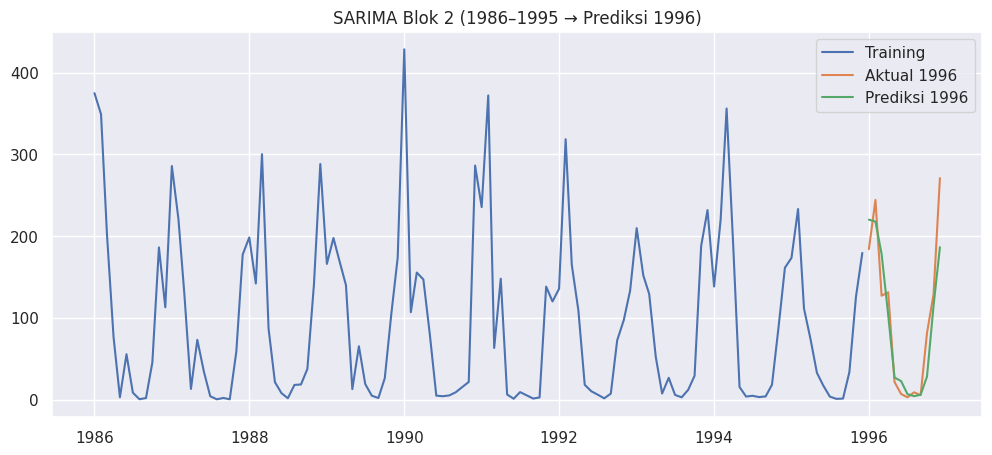

In [32]:
# ===============================
# SARIMA BLOK 2 (FULL 1 CELL)
# ===============================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# DATA TRAINING & AKTUAL
# ===============================
train_block2 = rain_series.loc['1986-01-01':'1995-12-01']
actual_1996 = rain_series.loc['1996-01-01':'1996-12-01']

print("Jumlah data training:", train_block2.shape)
print("Jumlah data aktual 1996:", actual_1996.shape)

# ===============================
# DEFINISI MODEL (FIX)
# ===============================
order = (0,0,1)
seasonal_order = (0,1,1,12)

# ===============================
# TRAINING
# ===============================
model_block2 = SARIMAX(
    train_block2,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_block2 = model_block2.fit(disp=False)

print("\nTraining selesai")

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_block2 = results_block2.predict(
    start=train_block2.index[0],
    end=train_block2.index[-1]
)

mae_train = mean_absolute_error(train_block2, train_pred_block2)
mse_train = mean_squared_error(train_block2, train_pred_block2)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_block2 - train_pred_block2) / train_block2)) * 100
r2_train = r2_score(train_block2, train_pred_block2)

print("\n=== ERROR TRAINING BLOK 2 ===")
print(f"MAE  : {mae_train:.4f}")
print(f"MSE  : {mse_train:.4f}")
print(f"RMSE : {rmse_train:.4f}")
print(f"MAPE : {mape_train:.2f}%")
print(f"R2   : {r2_train:.4f}")

# ===============================
# PREDIKSI 12 BULAN
# ===============================
forecast_block2 = results_block2.forecast(steps=12)

forecast_block2.index = actual_1996.index

forecast_block2_df = pd.DataFrame({
    'PREDIKSI_1996': forecast_block2
})

print("\n=== HASIL PREDIKSI 12 BULAN (1996) ===")
print(forecast_block2_df.round(2).to_string())

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_1996 = pd.DataFrame({
    'AKTUAL_1996': actual_1996,
    'PREDIKSI_1996': forecast_block2
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_1996.round(2).to_string())

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_1996, forecast_block2)
mse_pred = mean_squared_error(actual_1996, forecast_block2)
rmse_pred = np.sqrt(mse_pred)
mape_pred = np.mean(np.abs((actual_1996 - forecast_block2) / actual_1996)) * 100
r2_pred = r2_score(actual_1996, forecast_block2)

print("\n=== ERROR PREDIKSI 1996 ===")
print(f"MAE  : {mae_pred:.4f}")
print(f"MSE  : {mse_pred:.4f}")
print(f"RMSE : {rmse_pred:.4f}")
print(f"MAPE : {mape_pred:.2f}%")
print(f"R2   : {r2_pred:.4f}")

# ===============================
# SIMPAN HASIL BLOK 2
# ===============================
sarima_results.append({
    "block": 2,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "MAPE_Train": mape_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "MAPE_Pred": mape_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block2, label='Training')
plt.plot(actual_1996, label='Aktual 1996')
plt.plot(forecast_block2, label='Prediksi 1996')

plt.legend()
plt.title("SARIMA Blok 2 (1986–1995 → Prediksi 1996)")
plt.show()

# BLOK 3

Jumlah data training: (120,)
Jumlah data aktual 2001: (12,)

Training selesai

=== ERROR TRAINING BLOK 3 ===
MAE  : 43.1284
MSE  : 5096.0783
RMSE : 71.3868
MAPE : 108.19%
R2   : 0.4824

=== HASIL PREDIKSI 12 BULAN (2001) ===
            PREDIKSI_2001
DATE                     
2001-01-01         239.34
2001-02-01         242.17
2001-03-01         151.47
2001-04-01         135.90
2001-05-01          41.31
2001-06-01          15.20
2001-07-01          22.98
2001-08-01           7.24
2001-09-01          14.09
2001-10-01          81.08
2001-11-01         158.49
2001-12-01         196.95

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_2001  PREDIKSI_2001
DATE                                  
2001-01-01       170.44         239.34
2001-02-01       206.45         242.17
2001-03-01       148.22         151.47
2001-04-01       123.70         135.90
2001-05-01        12.01          41.31
2001-06-01        67.58          15.20
2001-07-01         3.32          22.98
2001-08-01         

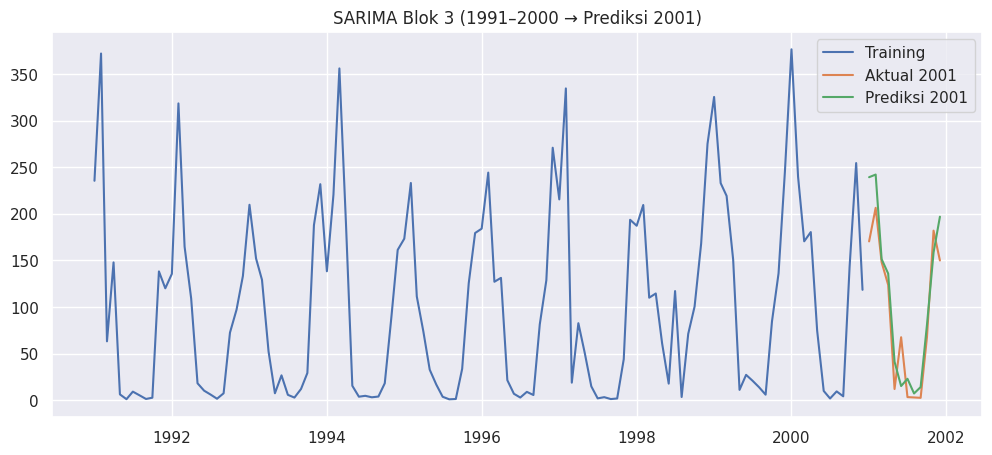

In [33]:
# ===============================
# SARIMA BLOK 3 (FULL 1 CELL)
# ===============================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# DATA TRAINING & AKTUAL
# ===============================
train_block3 = rain_series.loc['1991-01-01':'2000-12-01']
actual_2001 = rain_series.loc['2001-01-01':'2001-12-01']

print("Jumlah data training:", train_block3.shape)
print("Jumlah data aktual 2001:", actual_2001.shape)

# ===============================
# DEFINISI MODEL (FIX)
# ===============================
order = (0,0,1)
seasonal_order = (0,1,1,12)

# ===============================
# TRAINING
# ===============================
model_block3 = SARIMAX(
    train_block3,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_block3 = model_block3.fit(disp=False)

print("\nTraining selesai")

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_block3 = results_block3.predict(
    start=train_block3.index[0],
    end=train_block3.index[-1]
)

mae_train = mean_absolute_error(train_block3, train_pred_block3)
mse_train = mean_squared_error(train_block3, train_pred_block3)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_block3 - train_pred_block3) / train_block3)) * 100
r2_train = r2_score(train_block3, train_pred_block3)

print("\n=== ERROR TRAINING BLOK 3 ===")
print(f"MAE  : {mae_train:.4f}")
print(f"MSE  : {mse_train:.4f}")
print(f"RMSE : {rmse_train:.4f}")
print(f"MAPE : {mape_train:.2f}%")
print(f"R2   : {r2_train:.4f}")

# ===============================
# PREDIKSI 12 BULAN
# ===============================
forecast_block3 = results_block3.forecast(steps=12)

forecast_block3.index = actual_2001.index

forecast_block3_df = pd.DataFrame({
    'PREDIKSI_2001': forecast_block3
})

print("\n=== HASIL PREDIKSI 12 BULAN (2001) ===")
print(forecast_block3_df.round(2).to_string())

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_2001 = pd.DataFrame({
    'AKTUAL_2001': actual_2001,
    'PREDIKSI_2001': forecast_block3
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_2001.round(2).to_string())

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_2001, forecast_block3)
mse_pred = mean_squared_error(actual_2001, forecast_block3)
rmse_pred = np.sqrt(mse_pred)
mape_pred = np.mean(np.abs((actual_2001 - forecast_block3) / actual_2001)) * 100
r2_pred = r2_score(actual_2001, forecast_block3)

print("\n=== ERROR PREDIKSI 2001 ===")
print(f"MAE  : {mae_pred:.4f}")
print(f"MSE  : {mse_pred:.4f}")
print(f"RMSE : {rmse_pred:.4f}")
print(f"MAPE : {mape_pred:.2f}%")
print(f"R2   : {r2_pred:.4f}")

# ===============================
# SIMPAN HASIL BLOK 3
# ===============================
sarima_results.append({
    "block": 3,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "MAPE_Train": mape_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "MAPE_Pred": mape_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block3, label='Training')
plt.plot(actual_2001, label='Aktual 2001')
plt.plot(forecast_block3, label='Prediksi 2001')

plt.legend()
plt.title("SARIMA Blok 3 (1991–2000 → Prediksi 2001)")
plt.show()

# BLOK 4

Jumlah data training: (120,)
Jumlah data aktual 2006: (12,)

Training selesai

=== ERROR TRAINING BLOK 4 ===
MAE  : 49.0835
MSE  : 4973.8566
RMSE : 70.5256
MAPE : 233.84%
R2   : 0.5024

=== HASIL PREDIKSI 12 BULAN (2006) ===
            PREDIKSI_2006
DATE                     
2006-01-01         214.68
2006-02-01         252.25
2006-03-01         152.94
2006-04-01         121.35
2006-05-01          37.83
2006-06-01          18.82
2006-07-01          16.15
2006-08-01           6.14
2006-09-01          10.52
2006-10-01          57.99
2006-11-01         141.52
2006-12-01         221.57

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_2006  PREDIKSI_2006
DATE                                  
2006-01-01       221.73         214.68
2006-02-01       231.51         252.25
2006-03-01       198.98         152.94
2006-04-01       168.91         121.35
2006-05-01        73.56          37.83
2006-06-01         4.75          18.82
2006-07-01         1.09          16.15
2006-08-01         

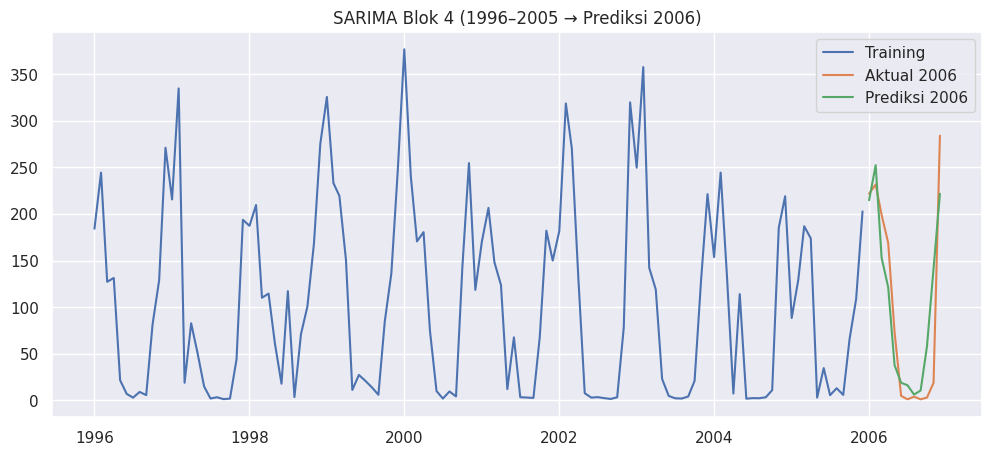

In [34]:
# ===============================
# SARIMA BLOK 4 (FULL 1 CELL)
# ===============================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# DATA TRAINING & AKTUAL
# ===============================
train_block4 = rain_series.loc['1996-01-01':'2005-12-01']
actual_2006 = rain_series.loc['2006-01-01':'2006-12-01']

print("Jumlah data training:", train_block4.shape)
print("Jumlah data aktual 2006:", actual_2006.shape)

# ===============================
# DEFINISI MODEL (FIX)
# ===============================
order = (0,0,1)
seasonal_order = (0,1,1,12)

# ===============================
# TRAINING
# ===============================
model_block4 = SARIMAX(
    train_block4,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_block4 = model_block4.fit(disp=False)

print("\nTraining selesai")

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_block4 = results_block4.predict(
    start=train_block4.index[0],
    end=train_block4.index[-1]
)

mae_train = mean_absolute_error(train_block4, train_pred_block4)
mse_train = mean_squared_error(train_block4, train_pred_block4)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_block4 - train_pred_block4) / train_block4)) * 100
r2_train = r2_score(train_block4, train_pred_block4)

print("\n=== ERROR TRAINING BLOK 4 ===")
print(f"MAE  : {mae_train:.4f}")
print(f"MSE  : {mse_train:.4f}")
print(f"RMSE : {rmse_train:.4f}")
print(f"MAPE : {mape_train:.2f}%")
print(f"R2   : {r2_train:.4f}")

# ===============================
# PREDIKSI 12 BULAN
# ===============================
forecast_block4 = results_block4.forecast(steps=12)

forecast_block4.index = actual_2006.index

forecast_block4_df = pd.DataFrame({
    'PREDIKSI_2006': forecast_block4
})

print("\n=== HASIL PREDIKSI 12 BULAN (2006) ===")
print(forecast_block4_df.round(2).to_string())

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_2006 = pd.DataFrame({
    'AKTUAL_2006': actual_2006,
    'PREDIKSI_2006': forecast_block4
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_2006.round(2).to_string())

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_2006, forecast_block4)
mse_pred = mean_squared_error(actual_2006, forecast_block4)
rmse_pred = np.sqrt(mse_pred)
mape_pred = np.mean(np.abs((actual_2006 - forecast_block4) / actual_2006)) * 100
r2_pred = r2_score(actual_2006, forecast_block4)

print("\n=== ERROR PREDIKSI 2006 ===")
print(f"MAE  : {mae_pred:.4f}")
print(f"MSE  : {mse_pred:.4f}")
print(f"RMSE : {rmse_pred:.4f}")
print(f"MAPE : {mape_pred:.2f}%")
print(f"R2   : {r2_pred:.4f}")

# ===============================
# SIMPAN HASIL BLOK 4
# ===============================
sarima_results.append({
    "block": 4,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "MAPE_Train": mape_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "MAPE_Pred": mape_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block4, label='Training')
plt.plot(actual_2006, label='Aktual 2006')
plt.plot(forecast_block4, label='Prediksi 2006')

plt.legend()
plt.title("SARIMA Blok 4 (1996–2005 → Prediksi 2006)")
plt.show()

# BLOK 5

Jumlah data training: (120,)
Jumlah data aktual 2011: (12,)

Training selesai

=== ERROR TRAINING BLOK 5 ===
MAE  : 49.8707
MSE  : 5437.0038
RMSE : 73.7360
MAPE : 191.43%
R2   : 0.4794

=== HASIL PREDIKSI 12 BULAN (2011) ===
            PREDIKSI_2011
DATE                     
2011-01-01         215.03
2011-02-01         222.77
2011-03-01         176.64
2011-04-01         101.20
2011-05-01          51.01
2011-06-01          18.46
2011-07-01          22.32
2011-08-01           4.78
2011-09-01          40.60
2011-10-01          40.22
2011-11-01         125.62
2011-12-01         245.22

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_2011  PREDIKSI_2011
DATE                                  
2011-01-01       252.99         215.03
2011-02-01       214.05         222.77
2011-03-01       172.84         176.64
2011-04-01       231.43         101.20
2011-05-01       159.05          51.01
2011-06-01         0.75          18.46
2011-07-01         0.65          22.32
2011-08-01         

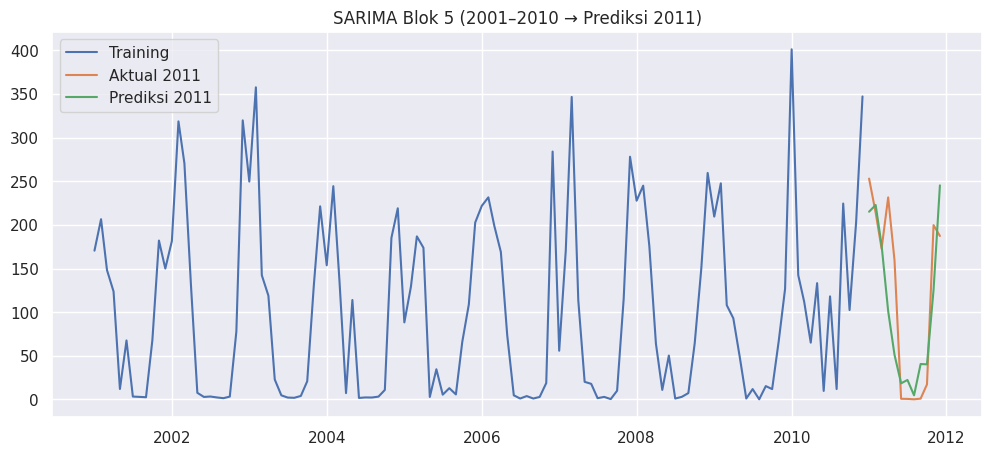

In [35]:
# ===============================
# SARIMA BLOK 5 (FULL 1 CELL)
# ===============================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# DATA TRAINING & AKTUAL
# ===============================
train_block5 = rain_series.loc['2001-01-01':'2010-12-01']
actual_2011 = rain_series.loc['2011-01-01':'2011-12-01']

print("Jumlah data training:", train_block5.shape)
print("Jumlah data aktual 2011:", actual_2011.shape)

# ===============================
# DEFINISI MODEL (FIX)
# ===============================
order = (0,0,1)
seasonal_order = (0,1,1,12)

# ===============================
# TRAINING
# ===============================
model_block5 = SARIMAX(
    train_block5,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_block5 = model_block5.fit(disp=False)

print("\nTraining selesai")

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_block5 = results_block5.predict(
    start=train_block5.index[0],
    end=train_block5.index[-1]
)

mae_train = mean_absolute_error(train_block5, train_pred_block5)
mse_train = mean_squared_error(train_block5, train_pred_block5)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_block5 - train_pred_block5) / train_block5)) * 100
r2_train = r2_score(train_block5, train_pred_block5)

print("\n=== ERROR TRAINING BLOK 5 ===")
print(f"MAE  : {mae_train:.4f}")
print(f"MSE  : {mse_train:.4f}")
print(f"RMSE : {rmse_train:.4f}")
print(f"MAPE : {mape_train:.2f}%")
print(f"R2   : {r2_train:.4f}")

# ===============================
# PREDIKSI 12 BULAN
# ===============================
forecast_block5 = results_block5.forecast(steps=12)

forecast_block5.index = actual_2011.index

forecast_block5_df = pd.DataFrame({
    'PREDIKSI_2011': forecast_block5
})

print("\n=== HASIL PREDIKSI 12 BULAN (2011) ===")
print(forecast_block5_df.round(2).to_string())

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_2011 = pd.DataFrame({
    'AKTUAL_2011': actual_2011,
    'PREDIKSI_2011': forecast_block5
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_2011.round(2).to_string())

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_2011, forecast_block5)
mse_pred = mean_squared_error(actual_2011, forecast_block5)
rmse_pred = np.sqrt(mse_pred)
mape_pred = np.mean(np.abs((actual_2011 - forecast_block5) / actual_2011)) * 100
r2_pred = r2_score(actual_2011, forecast_block5)

print("\n=== ERROR PREDIKSI 2011 ===")
print(f"MAE  : {mae_pred:.4f}")
print(f"MSE  : {mse_pred:.4f}")
print(f"RMSE : {rmse_pred:.4f}")
print(f"MAPE : {mape_pred:.2f}%")
print(f"R2   : {r2_pred:.4f}")

# ===============================
# SIMPAN HASIL BLOK 5
# ===============================
sarima_results.append({
    "block": 5,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "MAPE_Train": mape_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "MAPE_Pred": mape_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block5, label='Training')
plt.plot(actual_2011, label='Aktual 2011')
plt.plot(forecast_block5, label='Prediksi 2011')

plt.legend()
plt.title("SARIMA Blok 5 (2001–2010 → Prediksi 2011)")
plt.show()

# BLOK 6

Jumlah data training: (120,)
Jumlah data aktual 2016: (12,)

Training selesai

=== ERROR TRAINING BLOK 6 ===
MAE  : 57.5094
MSE  : 7114.4558
RMSE : 84.3472
MAPE : 499.44%
R2   : 0.3815

=== HASIL PREDIKSI 12 BULAN (2016) ===
            PREDIKSI_2016
DATE                     
2016-01-01         253.34
2016-02-01         191.27
2016-03-01         191.08
2016-04-01         120.14
2016-05-01          72.11
2016-06-01          22.46
2016-07-01          17.60
2016-08-01           2.68
2016-09-01          25.32
2016-10-01          23.51
2016-11-01         112.08
2016-12-01         240.14

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_2016  PREDIKSI_2016
DATE                                  
2016-01-01       264.52         253.34
2016-02-01       414.64         191.27
2016-03-01       158.53         191.08
2016-04-01        98.26         120.14
2016-05-01        56.35          72.11
2016-06-01       115.15          22.46
2016-07-01        66.79          17.60
2016-08-01        1

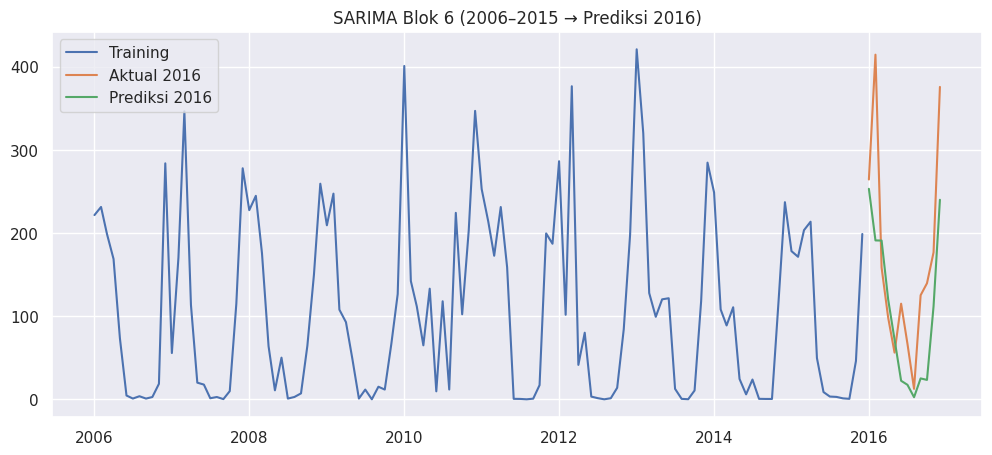

In [36]:
# ===============================
# SARIMA BLOK 6 (FULL 1 CELL)
# ===============================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# DATA TRAINING & AKTUAL
# ===============================
train_block6 = rain_series.loc['2006-01-01':'2015-12-01']
actual_2016 = rain_series.loc['2016-01-01':'2016-12-01']

print("Jumlah data training:", train_block6.shape)
print("Jumlah data aktual 2016:", actual_2016.shape)

# ===============================
# DEFINISI MODEL (FIX)
# ===============================
order = (0,0,1)
seasonal_order = (0,1,1,12)

# ===============================
# TRAINING
# ===============================
model_block6 = SARIMAX(
    train_block6,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_block6 = model_block6.fit(disp=False)

print("\nTraining selesai")

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_block6 = results_block6.predict(
    start=train_block6.index[0],
    end=train_block6.index[-1]
)

mae_train = mean_absolute_error(train_block6, train_pred_block6)
mse_train = mean_squared_error(train_block6, train_pred_block6)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_block6 - train_pred_block6) / train_block6)) * 100
r2_train = r2_score(train_block6, train_pred_block6)

print("\n=== ERROR TRAINING BLOK 6 ===")
print(f"MAE  : {mae_train:.4f}")
print(f"MSE  : {mse_train:.4f}")
print(f"RMSE : {rmse_train:.4f}")
print(f"MAPE : {mape_train:.2f}%")
print(f"R2   : {r2_train:.4f}")

# ===============================
# PREDIKSI 12 BULAN
# ===============================
forecast_block6 = results_block6.forecast(steps=12)

forecast_block6.index = actual_2016.index

forecast_block6_df = pd.DataFrame({
    'PREDIKSI_2016': forecast_block6
})

print("\n=== HASIL PREDIKSI 12 BULAN (2016) ===")
print(forecast_block6_df.round(2).to_string())

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_2016 = pd.DataFrame({
    'AKTUAL_2016': actual_2016,
    'PREDIKSI_2016': forecast_block6
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_2016.round(2).to_string())

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_2016, forecast_block6)
mse_pred = mean_squared_error(actual_2016, forecast_block6)
rmse_pred = np.sqrt(mse_pred)
mape_pred = np.mean(np.abs((actual_2016 - forecast_block6) / actual_2016)) * 100
r2_pred = r2_score(actual_2016, forecast_block6)

print("\n=== ERROR PREDIKSI 2016 ===")
print(f"MAE  : {mae_pred:.4f}")
print(f"MSE  : {mse_pred:.4f}")
print(f"RMSE : {rmse_pred:.4f}")
print(f"MAPE : {mape_pred:.2f}%")
print(f"R2   : {r2_pred:.4f}")

# ===============================
# SIMPAN HASIL BLOK 6
# ===============================
sarima_results.append({
    "block": 6,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "MAPE_Train": mape_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "MAPE_Pred": mape_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block6, label='Training')
plt.plot(actual_2016, label='Aktual 2016')
plt.plot(forecast_block6, label='Prediksi 2016')

plt.legend()
plt.title("SARIMA Blok 6 (2006–2015 → Prediksi 2016)")
plt.show()

# BLOK 7

Jumlah data training: (120,)
Jumlah data aktual 2021: (12,)

Training selesai

=== ERROR TRAINING BLOK 7 ===
MAE  : 58.7284
MSE  : 7566.6087
RMSE : 86.9863
MAPE : 139.99%
R2   : 0.4339

=== HASIL PREDIKSI 12 BULAN (2021) ===
            PREDIKSI_2021
DATE                     
2021-01-01         312.16
2021-02-01         232.33
2021-03-01         210.64
2021-04-01         115.57
2021-05-01          67.33
2021-06-01          35.59
2021-07-01          14.46
2021-08-01           9.11
2021-09-01          16.36
2021-10-01          35.16
2021-11-01         142.46
2021-12-01         234.26

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_2021  PREDIKSI_2021
DATE                                  
2021-01-01       317.18         312.16
2021-02-01       362.96         232.33
2021-03-01       183.83         210.64
2021-04-01        96.28         115.57
2021-05-01        22.04          67.33
2021-06-01        61.22          35.59
2021-07-01         8.63          14.46
2021-08-01        1

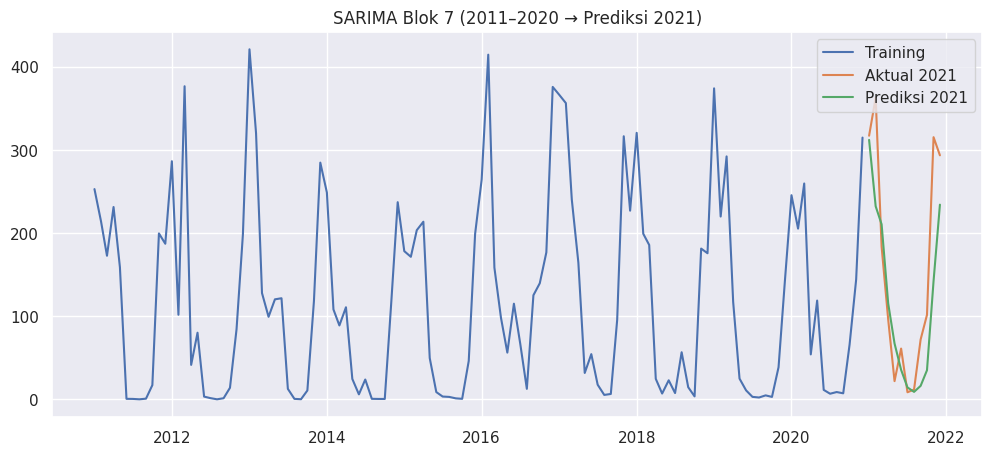

In [37]:
# ===============================
# SARIMA BLOK 7 (FULL 1 CELL)
# ===============================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# DATA TRAINING & AKTUAL
# ===============================
train_block7 = rain_series.loc['2011-01-01':'2020-12-01']
actual_2021 = rain_series.loc['2021-01-01':'2021-12-01']

print("Jumlah data training:", train_block7.shape)
print("Jumlah data aktual 2021:", actual_2021.shape)

# ===============================
# DEFINISI MODEL (FIX)
# ===============================
order = (0,0,1)
seasonal_order = (0,1,1,12)

# ===============================
# TRAINING
# ===============================
model_block7 = SARIMAX(
    train_block7,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_block7 = model_block7.fit(disp=False)

print("\nTraining selesai")

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_block7 = results_block7.predict(
    start=train_block7.index[0],
    end=train_block7.index[-1]
)

mae_train = mean_absolute_error(train_block7, train_pred_block7)
mse_train = mean_squared_error(train_block7, train_pred_block7)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_block7 - train_pred_block7) / train_block7)) * 100
r2_train = r2_score(train_block7, train_pred_block7)

print("\n=== ERROR TRAINING BLOK 7 ===")
print(f"MAE  : {mae_train:.4f}")
print(f"MSE  : {mse_train:.4f}")
print(f"RMSE : {rmse_train:.4f}")
print(f"MAPE : {mape_train:.2f}%")
print(f"R2   : {r2_train:.4f}")

# ===============================
# PREDIKSI 12 BULAN
# ===============================
forecast_block7 = results_block7.forecast(steps=12)

forecast_block7.index = actual_2021.index

forecast_block7_df = pd.DataFrame({
    'PREDIKSI_2021': forecast_block7
})

print("\n=== HASIL PREDIKSI 12 BULAN (2021) ===")
print(forecast_block7_df.round(2).to_string())

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_2021 = pd.DataFrame({
    'AKTUAL_2021': actual_2021,
    'PREDIKSI_2021': forecast_block7
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_2021.round(2).to_string())

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_2021, forecast_block7)
mse_pred = mean_squared_error(actual_2021, forecast_block7)
rmse_pred = np.sqrt(mse_pred)
mape_pred = np.mean(np.abs((actual_2021 - forecast_block7) / actual_2021)) * 100
r2_pred = r2_score(actual_2021, forecast_block7)

print("\n=== ERROR PREDIKSI 2021 ===")
print(f"MAE  : {mae_pred:.4f}")
print(f"MSE  : {mse_pred:.4f}")
print(f"RMSE : {rmse_pred:.4f}")
print(f"MAPE : {mape_pred:.2f}%")
print(f"R2   : {r2_pred:.4f}")

# ===============================
# SIMPAN HASIL BLOK 7
# ===============================
sarima_results.append({
    "block": 7,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "MAPE_Train": mape_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "MAPE_Pred": mape_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block7, label='Training')
plt.plot(actual_2021, label='Aktual 2021')
plt.plot(forecast_block7, label='Prediksi 2021')

plt.legend()
plt.title("SARIMA Blok 7 (2011–2020 → Prediksi 2021)")
plt.show()

# BLOK 8

PREDIKSI 2026
              Prediksi
2026-01-01  279.679422
2026-02-01  266.301435
2026-03-01  223.917976
2026-04-01  103.459761
2026-05-01   44.155126
2026-06-01   40.973577
2026-07-01   20.759543
2026-08-01   12.634822
2026-09-01   32.291821
2026-10-01   73.625089
2026-11-01  179.158048
2026-12-01  260.933646


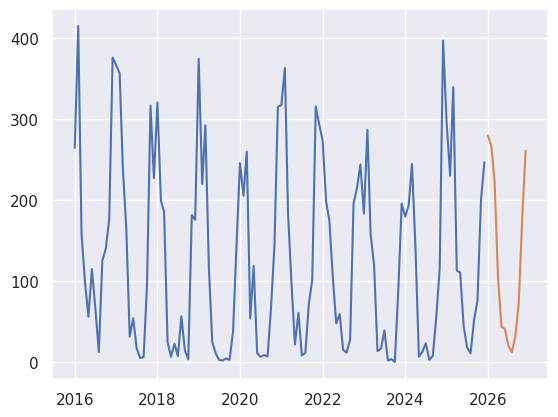

In [38]:
# SARIMA BLOK 8

train_block = rain_series.loc['2016-01-01':'2025-12-01']

model = SARIMAX(train_block, order=(0,0,1), seasonal_order=(0,1,1,12))
results = model.fit(disp=False)

forecast = results.forecast(steps=12)

print("PREDIKSI 2026")
print(pd.DataFrame({'Prediksi':forecast}))

plt.plot(train_block)
plt.plot(forecast)
plt.show()

# REKAP SARIMA (RATA-RATA)

In [39]:
# ===============================
# REKAP RATA-RATA SARIMA
# ===============================

import numpy as np
import pandas as pd

# Extract metrics from sarima_results
mae_train_list = [res['MAE_Train'] for res in sarima_results]
mse_train_list = [res['MSE_Train'] for res in sarima_results]
rmse_train_list = [res['RMSE_Train'] for res in sarima_results]
mape_train_list = [res['MAPE_Train'] for res in sarima_results]
r2_train_list = [res['R2_Train'] for res in sarima_results]

mae_pred_list = [res['MAE_Pred'] for res in sarima_results]
mse_pred_list = [res['MSE_Pred'] for res in sarima_results]
rmse_pred_list = [res['RMSE_Pred'] for res in sarima_results]
mape_pred_list = [res['MAPE_Pred'] for res in sarima_results]
r2_pred_list = [res['R2_Pred'] for res in sarima_results]

# ===============================
# PRINT HASIL RAPI
# ===============================

print("=== RATA-RATA SARIMA ===")

print("\n--- TRAINING ---")
print(f"MAE  : {np.mean(mae_train_list):.4f}")
print(f"MSE  : {np.mean(mse_train_list):.4f}")
print(f"RMSE : {np.mean(rmse_train_list):.4f}")
print(f"MAPE : {np.mean(mape_train_list):.2f}%")
print(f"R2   : {np.mean(r2_train_list):.4f}")

print("\n--- PREDIKSI ---")
print(f"MAE  : {np.mean(mae_pred_list):.4f}")
print(f"MSE  : {np.mean(mse_pred_list):.4f}")
print(f"RMSE : {np.mean(rmse_pred_list):.4f}")
print(f"MAPE : {np.mean(mape_pred_list):.2f}%")
print(f"R2   : {np.mean(r2_pred_list):.4f}")

=== RATA-RATA SARIMA ===

--- TRAINING ---
MAE  : 52.3290
MSE  : 6355.9479
RMSE : 79.4075
MAPE : 276.28%
R2   : 0.4263

--- PREDIKSI ---
MAE  : 43.1026
MSE  : 3766.7530
RMSE : 58.0654
MAPE : 328.13%
R2   : 0.6903


# AMBP


# BLOK 1

ini ada hasil MINUS


Training size: (120,)
Actual 1991 size: (12,)
X shape: (108, 12)
y shape: (108, 1)

Training selesai

=== ERROR TRAINING BLOK 1 ===
MAE : 53.68990453357505
MSE : 5090.319983932358
RMSE: 71.34647842698585
MAPE: 983.6005669886912
R2  : 0.5505939466272671

=== HASIL PREDIKSI 12 BULAN (1991) ===
DATE
1991-01-01    229.204783
1991-02-01    224.525330
1991-03-01    186.914041
1991-04-01    130.588351
1991-05-01     50.949435
1991-06-01     65.325633
1991-07-01    -26.573032
1991-08-01     -3.883788
1991-09-01      2.812225
1991-10-01     53.208958
1991-11-01    118.232895
1991-12-01    207.938088
Freq: MS, dtype: float64

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_1991  PREDIKSI_1991
DATE                                  
1991-01-01       235.49     229.204783
1991-02-01       372.08     224.525330
1991-03-01        63.19     186.914041
1991-04-01       147.90     130.588351
1991-05-01         6.26      50.949435
1991-06-01         1.11      65.325633
1991-07-01         9.20 

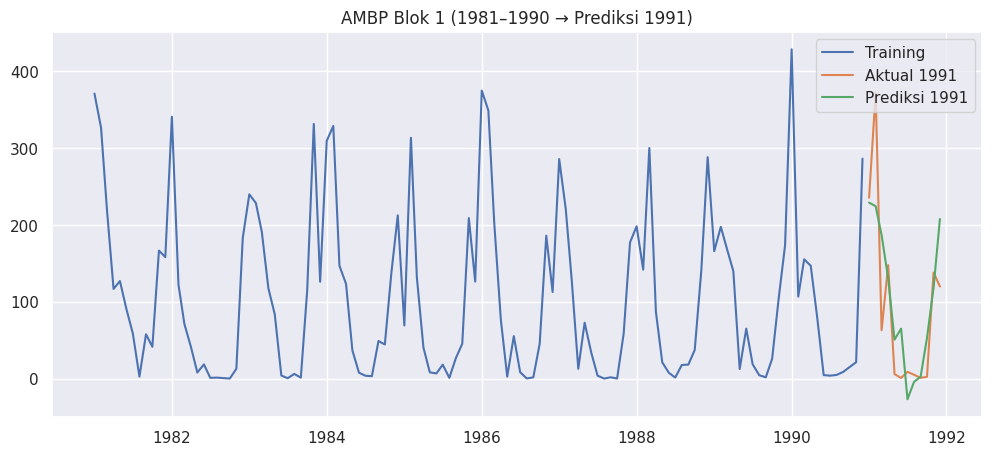

In [40]:
# ==============================
# AMBP BLOK 1
# ==============================

# Library AMBP (Neural Network)
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# DATA
# ==============================
train_block1 = rain_series['1981-01-01':'1990-12-01']
actual_1991 = rain_series['1991-01-01':'1991-12-01']

print("Training size:", train_block1.shape)
print("Actual 1991 size:", actual_1991.shape)

# ==============================
# NORMALISASI
# ==============================
scaler_block1 = MinMaxScaler()

train_scaled_block1 = scaler_block1.fit_transform(
    train_block1.values.reshape(-1,1)
)

# ==============================
# FUNGSI LAG
# ==============================
def create_lagged_data(data, lag):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y)

lag = 12

X_train_b1, y_train_b1 = create_lagged_data(train_scaled_block1, lag)

print("X shape:", X_train_b1.shape)
print("y shape:", y_train_b1.shape)

# ==============================
# MODEL AMBP
# ==============================
model_b1 = MLPRegressor(
    hidden_layer_sizes=(10,),
    activation='relu',
    solver='adam',
    max_iter=2000,
    early_stopping=True,
    random_state=42
)

model_b1.fit(X_train_b1, y_train_b1.ravel())

print("\nTraining selesai")

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_scaled = model_b1.predict(X_train_b1)

train_pred = scaler_block1.inverse_transform(
    train_pred_scaled.reshape(-1,1)
)

train_actual = scaler_block1.inverse_transform(y_train_b1)

mae_train = mean_absolute_error(train_actual, train_pred)
mse_train = mean_squared_error(train_actual, train_pred)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_actual - train_pred)/train_actual))*100
r2_train = r2_score(train_actual, train_pred)

print("\n=== ERROR TRAINING BLOK 1 ===")
print("MAE :", mae_train)
print("MSE :", mse_train)
print("RMSE:", rmse_train)
print("MAPE:", mape_train)
print("R2  :", r2_train)

# ===============================
# PREDIKSI 12 BULAN
# ===============================
last_12_months = train_scaled_block1[-lag:]

forecast_scaled = []

current_input = last_12_months.copy()

for i in range(12):
    pred = model_b1.predict(current_input.reshape(1,-1))
    forecast_scaled.append(pred[0])
    current_input = np.append(current_input[1:], pred)

forecast_block1 = scaler_block1.inverse_transform(
    np.array(forecast_scaled).reshape(-1,1)
).flatten()

forecast_block1 = pd.Series(
    forecast_block1,
    index=actual_1991.index
)

print("\n=== HASIL PREDIKSI 12 BULAN (1991) ===")
print(forecast_block1)

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_1991 = pd.DataFrame({
    'AKTUAL_1991': actual_1991,
    'PREDIKSI_1991': forecast_block1
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_1991)

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_1991, forecast_block1)
mse_pred = mean_squared_error(actual_1991, forecast_block1)
rmse_pred = np.sqrt(mse_pred)
mape_pred = np.mean(np.abs((actual_1991 - forecast_block1)/actual_1991))*100
r2_pred = r2_score(actual_1991, forecast_block1)

print("\n=== ERROR PREDIKSI 1991 ===")
print("MAE :", mae_pred)
print("MSE :", mse_pred)
print("RMSE:", rmse_pred)
print("MAPE:", mape_pred)
print("R2  :", r2_pred)

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block1.index, train_block1, label="Training")
plt.plot(actual_1991.index, actual_1991, label="Aktual 1991")
plt.plot(forecast_block1.index, forecast_block1, label="Prediksi 1991")

plt.title("AMBP Blok 1 (1981–1990 → Prediksi 1991)")
plt.legend()
plt.show()

# BLOK 2

ERROR TRAINING BLOK 2
45.831491708325885 3717.4526400426366 60.970916345767975 568.8661606940462 0.619075640102213
DATE
1996-01-01    212.711994
1996-02-01    200.427118
1996-03-01    161.170715
1996-04-01    112.245914
1996-05-01     70.140120
1996-06-01     21.576918
1996-07-01      7.310162
1996-08-01      2.235394
1996-09-01     20.191843
1996-10-01     62.786631
1996-11-01    125.889562
1996-12-01    173.113418
Freq: MS, dtype: float64
            Aktual    Prediksi
DATE                          
1996-01-01  184.10  212.711994
1996-02-01  244.27  200.427118
1996-03-01  127.13  161.170715
1996-04-01  131.29  112.245914
1996-05-01   21.51   70.140120
1996-06-01    6.90   21.576918
1996-07-01    2.86    7.310162
1996-08-01    8.96    2.235394
1996-09-01    5.58   20.191843
1996-10-01   81.41   62.786631
1996-11-01  128.81  125.889562
1996-12-01  270.97  173.113418
ERROR PREDIKSI BLOK 2
27.8361428877207 1421.0326840061487 37.69658716656123 88.94427613395601 0.8319301161954422


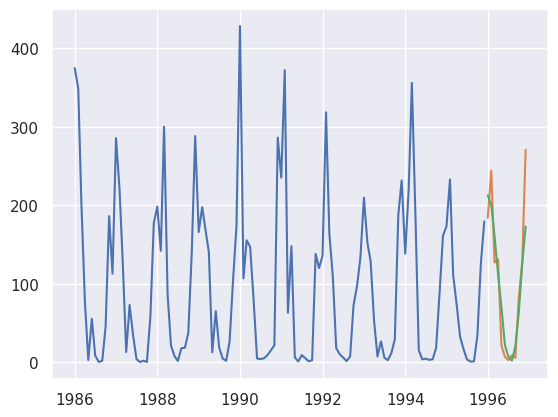

In [41]:
# ==============================
# AMBP BLOK 2 (FULL 1 CELL)
# ==============================

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_block = rain_series['1986-01-01':'1995-12-01']
actual = rain_series['1996-01-01':'1996-12-01']

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_block.values.reshape(-1,1))

def create_lagged_data(data, lag):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y)

lag = 12
X_train, y_train = create_lagged_data(train_scaled, lag)

model = MLPRegressor(hidden_layer_sizes=(10,), activation='relu', solver='adam', max_iter=2000, early_stopping=True, random_state=42)
model.fit(X_train, y_train.ravel())

train_pred_scaled = model.predict(X_train)
train_pred = scaler.inverse_transform(train_pred_scaled.reshape(-1,1))
train_actual = scaler.inverse_transform(y_train)

mae_train = mean_absolute_error(train_actual, train_pred)
mse_train = mean_squared_error(train_actual, train_pred)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_actual-train_pred)/train_actual))*100
r2_train = r2_score(train_actual, train_pred)

print("ERROR TRAINING BLOK 2")
print(mae_train, mse_train, rmse_train, mape_train, r2_train)

last = train_scaled[-lag:]
forecast_scaled = []
cur = last.copy()

for i in range(12):
    p = model.predict(cur.reshape(1,-1))
    forecast_scaled.append(p[0])
    cur = np.append(cur[1:], p)

forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1,1)).flatten()
forecast = pd.Series(forecast, index=actual.index)

print(forecast)

print(pd.DataFrame({'Aktual':actual,'Prediksi':forecast}))

mae = mean_absolute_error(actual, forecast)
mse = mean_squared_error(actual, forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual-forecast)/actual))*100
r2 = r2_score(actual, forecast)

print("ERROR PREDIKSI BLOK 2")
print(mae, mse, rmse, mape, r2)

plt.plot(train_block)
plt.plot(actual)
plt.plot(forecast)
plt.show()

# BLOK 3

ERROR TRAINING BLOK 2
44.1342631317226 3321.0152949333537 57.628250840480604 362.6526051642392 0.6512158633278184
DATE
2001-01-01    191.594015
2001-02-01    189.865879
2001-03-01    137.589995
2001-04-01    135.953112
2001-05-01     45.906554
2001-06-01    -15.251100
2001-07-01     25.973964
2001-08-01     35.044362
2001-09-01     79.806082
2001-10-01    133.139395
2001-11-01    160.744103
2001-12-01    179.548522
Freq: MS, dtype: float64
            Aktual    Prediksi
DATE                          
2001-01-01  170.44  191.594015
2001-02-01  206.45  189.865879
2001-03-01  148.22  137.589995
2001-04-01  123.70  135.953112
2001-05-01   12.01   45.906554
2001-06-01   67.58  -15.251100
2001-07-01    3.32   25.973964
2001-08-01    2.96   35.044362
2001-09-01    2.55   79.806082
2001-10-01   67.96  133.139395
2001-11-01  181.99  160.744103
2001-12-01  149.95  179.548522
ERROR PREDIKSI BLOK 2
35.447260780891476 1840.2127857476314 42.89770140401035 447.13138335316637 0.6661663520592391


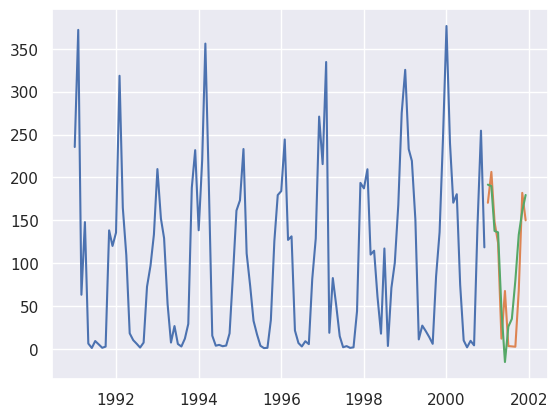

In [42]:
# ==============================
# AMBP BLOK 3
# ==============================

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_block = rain_series['1991-01-01':'2000-12-01']
actual = rain_series['2001-01-01':'2001-12-01']

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_block.values.reshape(-1,1))

def create_lagged_data(data, lag):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y)

lag = 12
X_train, y_train = create_lagged_data(train_scaled, lag)

model = MLPRegressor(hidden_layer_sizes=(10,), activation='relu', solver='adam', max_iter=2000, early_stopping=True, random_state=42)
model.fit(X_train, y_train.ravel())

train_pred_scaled = model.predict(X_train)
train_pred = scaler.inverse_transform(train_pred_scaled.reshape(-1,1))
train_actual = scaler.inverse_transform(y_train)

mae_train = mean_absolute_error(train_actual, train_pred)
mse_train = mean_squared_error(train_actual, train_pred)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_actual-train_pred)/train_actual))*100
r2_train = r2_score(train_actual, train_pred)

print("ERROR TRAINING BLOK 2")
print(mae_train, mse_train, rmse_train, mape_train, r2_train)

last = train_scaled[-lag:]
forecast_scaled = []
cur = last.copy()

for i in range(12):
    p = model.predict(cur.reshape(1,-1))
    forecast_scaled.append(p[0])
    cur = np.append(cur[1:], p)

forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1,1)).flatten()
forecast = pd.Series(forecast, index=actual.index)

print(forecast)

print(pd.DataFrame({'Aktual':actual,'Prediksi':forecast}))

mae = mean_absolute_error(actual, forecast)
mse = mean_squared_error(actual, forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual-forecast)/actual))*100
r2 = r2_score(actual, forecast)

print("ERROR PREDIKSI BLOK 2")
print(mae, mse, rmse, mape, r2)

plt.plot(train_block)
plt.plot(actual)
plt.plot(forecast)
plt.show()

# BLOK 4

ERROR TRAINING BLOK 2
54.74752089400908 4802.936829732375 69.30322380475799 578.4857982145454 0.5274986314508154
DATE
2006-01-01    182.048813
2006-02-01    197.858054
2006-03-01    140.778163
2006-04-01    162.632006
2006-05-01    102.232857
2006-06-01    109.063953
2006-07-01     30.862607
2006-08-01     51.455231
2006-09-01     25.960609
2006-10-01    104.033044
2006-11-01     84.486728
2006-12-01    172.429902
Freq: MS, dtype: float64
            Aktual    Prediksi
DATE                          
2006-01-01  221.73  182.048813
2006-02-01  231.51  197.858054
2006-03-01  198.98  140.778163
2006-04-01  168.91  162.632006
2006-05-01   73.56  102.232857
2006-06-01    4.75  109.063953
2006-07-01    1.09   30.862607
2006-08-01    3.87   51.455231
2006-09-01    1.07   25.960609
2006-10-01    2.91  104.033044
2006-11-01   18.80   84.486728
2006-12-01  283.96  172.429902
ERROR PREDIKSI BLOK 2
54.28234093986021 4048.9445267553565 63.631317185450094 1037.6169483815167 0.6403402415711021


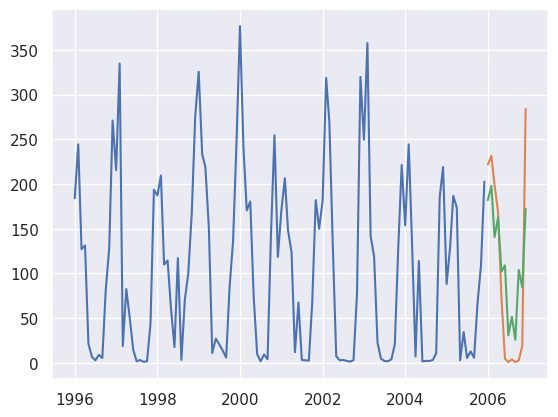

In [43]:
# ==============================
# AMBP BLOK 4
# ==============================

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_block = rain_series['1996-01-01':'2005-12-01']
actual = rain_series['2006-01-01':'2006-12-01']

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_block.values.reshape(-1,1))

def create_lagged_data(data, lag):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y)

lag = 12
X_train, y_train = create_lagged_data(train_scaled, lag)

model = MLPRegressor(hidden_layer_sizes=(10,), activation='relu', solver='adam', max_iter=2000, early_stopping=True, random_state=42)
model.fit(X_train, y_train.ravel())

train_pred_scaled = model.predict(X_train)
train_pred = scaler.inverse_transform(train_pred_scaled.reshape(-1,1))
train_actual = scaler.inverse_transform(y_train)

mae_train = mean_absolute_error(train_actual, train_pred)
mse_train = mean_squared_error(train_actual, train_pred)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_actual-train_pred)/train_actual))*100
r2_train = r2_score(train_actual, train_pred)

print("ERROR TRAINING BLOK 2")
print(mae_train, mse_train, rmse_train, mape_train, r2_train)

last = train_scaled[-lag:]
forecast_scaled = []
cur = last.copy()

for i in range(12):
    p = model.predict(cur.reshape(1,-1))
    forecast_scaled.append(p[0])
    cur = np.append(cur[1:], p)

forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1,1)).flatten()
forecast = pd.Series(forecast, index=actual.index)

print(forecast)

print(pd.DataFrame({'Aktual':actual,'Prediksi':forecast}))

mae = mean_absolute_error(actual, forecast)
mse = mean_squared_error(actual, forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual-forecast)/actual))*100
r2 = r2_score(actual, forecast)

print("ERROR PREDIKSI BLOK 2")
print(mae, mse, rmse, mape, r2)

plt.plot(train_block)
plt.plot(actual)
plt.plot(forecast)
plt.show()

# BLOK 5

ERROR TRAINING BLOK 2
55.21280451914704 5652.110483073076 75.18051930568899 707.2569185823714 0.4854335326454532
DATE
2011-01-01    200.449452
2011-02-01     89.197302
2011-03-01    163.280558
2011-04-01      4.041006
2011-05-01     73.702448
2011-06-01     21.545491
2011-07-01    -11.763799
2011-08-01      7.462222
2011-09-01    121.415149
2011-10-01     98.173595
2011-11-01    201.754955
2011-12-01    164.581385
Freq: MS, dtype: float64
            Aktual    Prediksi
DATE                          
2011-01-01  252.99  200.449452
2011-02-01  214.05   89.197302
2011-03-01  172.84  163.280558
2011-04-01  231.43    4.041006
2011-05-01  159.05   73.702448
2011-06-01    0.75   21.545491
2011-07-01    0.65  -11.763799
2011-08-01    0.18    7.462222
2011-09-01    0.96  121.415149
2011-10-01   17.23   98.173595
2011-11-01  199.69  201.754955
2011-12-01  187.26  164.581385
ERROR PREDIKSI BLOK 2
63.86025492321613 8304.127074506001 91.1269832404541 1832.9256080394719 0.18114045001279733


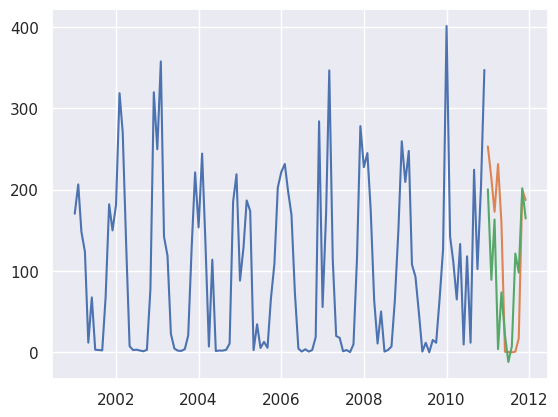

In [44]:
# ==============================
# AMBP BLOK 5
# ==============================

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_block = rain_series['2001-01-01':'2010-12-01']
actual = rain_series['2011-01-01':'2011-12-01']

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_block.values.reshape(-1,1))

def create_lagged_data(data, lag):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y)

lag = 12
X_train, y_train = create_lagged_data(train_scaled, lag)

model = MLPRegressor(hidden_layer_sizes=(10,), activation='relu', solver='adam', max_iter=2000, early_stopping=True, random_state=42)
model.fit(X_train, y_train.ravel())

train_pred_scaled = model.predict(X_train)
train_pred = scaler.inverse_transform(train_pred_scaled.reshape(-1,1))
train_actual = scaler.inverse_transform(y_train)

mae_train = mean_absolute_error(train_actual, train_pred)
mse_train = mean_squared_error(train_actual, train_pred)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_actual-train_pred)/train_actual))*100
r2_train = r2_score(train_actual, train_pred)

print("ERROR TRAINING BLOK 2")
print(mae_train, mse_train, rmse_train, mape_train, r2_train)

last = train_scaled[-lag:]
forecast_scaled = []
cur = last.copy()

for i in range(12):
    p = model.predict(cur.reshape(1,-1))
    forecast_scaled.append(p[0])
    cur = np.append(cur[1:], p)

forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1,1)).flatten()
forecast = pd.Series(forecast, index=actual.index)

print(forecast)

print(pd.DataFrame({'Aktual':actual,'Prediksi':forecast}))

mae = mean_absolute_error(actual, forecast)
mse = mean_squared_error(actual, forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual-forecast)/actual))*100
r2 = r2_score(actual, forecast)

print("ERROR PREDIKSI BLOK 2")
print(mae, mse, rmse, mape, r2)

plt.plot(train_block)
plt.plot(actual)
plt.plot(forecast)
plt.show()

# BLOK 6

ERROR TRAINING BLOK 2
75.10162841272818 8801.886462452145 93.8183695363128 2039.9084610703312 0.23639288664674318
DATE
2016-01-01    188.731872
2016-02-01    211.509537
2016-03-01    127.684810
2016-04-01    159.820365
2016-05-01    153.291206
2016-06-01    164.764027
2016-07-01     78.939186
2016-08-01     87.214880
2016-09-01     24.860076
2016-10-01     92.412490
2016-11-01     83.336666
2016-12-01    138.258778
Freq: MS, dtype: float64
            Aktual    Prediksi
DATE                          
2016-01-01  264.52  188.731872
2016-02-01  414.64  211.509537
2016-03-01  158.53  127.684810
2016-04-01   98.26  159.820365
2016-05-01   56.35  153.291206
2016-06-01  115.15  164.764027
2016-07-01   66.79   78.939186
2016-08-01   12.76   87.214880
2016-09-01  125.35   24.860076
2016-10-01  139.74   92.412490
2016-11-01  176.90   83.336666
2016-12-01  375.86  138.258778
ERROR PREDIKSI BLOK 2
90.28878631163762 12236.980548645379 110.62088658406864 100.55856031921434 0.1392248113481409


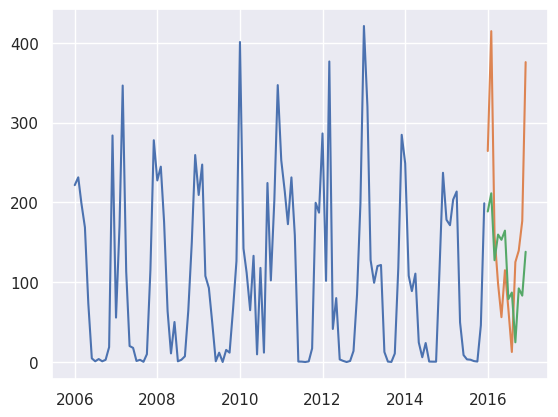

In [45]:
# ==============================
# AMBP BLOK 6
# ==============================

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_block = rain_series['2006-01-01':'2015-12-01']
actual = rain_series['2016-01-01':'2016-12-01']

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_block.values.reshape(-1,1))

def create_lagged_data(data, lag):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y)

lag = 12
X_train, y_train = create_lagged_data(train_scaled, lag)

model = MLPRegressor(hidden_layer_sizes=(10,), activation='relu', solver='adam', max_iter=2000, early_stopping=True, random_state=42)
model.fit(X_train, y_train.ravel())

train_pred_scaled = model.predict(X_train)
train_pred = scaler.inverse_transform(train_pred_scaled.reshape(-1,1))
train_actual = scaler.inverse_transform(y_train)

mae_train = mean_absolute_error(train_actual, train_pred)
mse_train = mean_squared_error(train_actual, train_pred)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_actual-train_pred)/train_actual))*100
r2_train = r2_score(train_actual, train_pred)

print("ERROR TRAINING BLOK 2")
print(mae_train, mse_train, rmse_train, mape_train, r2_train)

last = train_scaled[-lag:]
forecast_scaled = []
cur = last.copy()

for i in range(12):
    p = model.predict(cur.reshape(1,-1))
    forecast_scaled.append(p[0])
    cur = np.append(cur[1:], p)

forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1,1)).flatten()
forecast = pd.Series(forecast, index=actual.index)

print(forecast)

print(pd.DataFrame({'Aktual':actual,'Prediksi':forecast}))

mae = mean_absolute_error(actual, forecast)
mse = mean_squared_error(actual, forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual-forecast)/actual))*100
r2 = r2_score(actual, forecast)

print("ERROR PREDIKSI BLOK 2")
print(mae, mse, rmse, mape, r2)

plt.plot(train_block)
plt.plot(actual)
plt.plot(forecast)
plt.show()

# BLOK 7

ERROR TRAINING BLOK 2
58.18375516700568 5162.047876286414 71.84739296791787 1049.7258710723488 0.6238279552770664
DATE
2021-01-01    271.411949
2021-02-01    223.460691
2021-03-01    184.404710
2021-04-01    106.479244
2021-05-01     41.966732
2021-06-01     26.686847
2021-07-01    -14.114796
2021-08-01     -5.382795
2021-09-01     36.061461
2021-10-01     90.731552
2021-11-01    185.446177
2021-12-01    260.557910
Freq: MS, dtype: float64
            Aktual    Prediksi
DATE                          
2021-01-01  317.18  271.411949
2021-02-01  362.96  223.460691
2021-03-01  183.83  184.404710
2021-04-01   96.28  106.479244
2021-05-01   22.04   41.966732
2021-06-01   61.22   26.686847
2021-07-01    8.63  -14.114796
2021-08-01   11.91   -5.382795
2021-09-01   72.10   36.061461
2021-10-01  101.73   90.731552
2021-11-01  315.43  185.446177
2021-12-01  293.60  260.557910
ERROR PREDIKSI BLOK 2
41.71680743048852 3622.7018666762665 60.188884909726205 61.04983714199547 0.7791534428978182


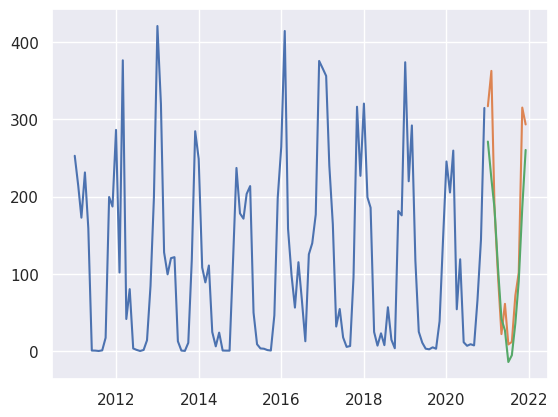

In [46]:
# ==============================
# AMBP BLOK 7
# ==============================

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_block = rain_series['2011-01-01':'2020-12-01']
actual = rain_series['2021-01-01':'2021-12-01']

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_block.values.reshape(-1,1))

def create_lagged_data(data, lag):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y)

lag = 12
X_train, y_train = create_lagged_data(train_scaled, lag)

model = MLPRegressor(hidden_layer_sizes=(10,), activation='relu', solver='adam', max_iter=2000, early_stopping=True, random_state=42)
model.fit(X_train, y_train.ravel())

train_pred_scaled = model.predict(X_train)
train_pred = scaler.inverse_transform(train_pred_scaled.reshape(-1,1))
train_actual = scaler.inverse_transform(y_train)

mae_train = mean_absolute_error(train_actual, train_pred)
mse_train = mean_squared_error(train_actual, train_pred)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_actual-train_pred)/train_actual))*100
r2_train = r2_score(train_actual, train_pred)

print("ERROR TRAINING BLOK 2")
print(mae_train, mse_train, rmse_train, mape_train, r2_train)

last = train_scaled[-lag:]
forecast_scaled = []
cur = last.copy()

for i in range(12):
    p = model.predict(cur.reshape(1,-1))
    forecast_scaled.append(p[0])
    cur = np.append(cur[1:], p)

forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1,1)).flatten()
forecast = pd.Series(forecast, index=actual.index)

print(forecast)

print(pd.DataFrame({'Aktual':actual,'Prediksi':forecast}))

mae = mean_absolute_error(actual, forecast)
mse = mean_squared_error(actual, forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual-forecast)/actual))*100
r2 = r2_score(actual, forecast)

print("ERROR PREDIKSI BLOK 2")
print(mae, mse, rmse, mape, r2)

plt.plot(train_block)
plt.plot(actual)
plt.plot(forecast)
plt.show()

# BLOK 8

PREDIKSI 2026
[277.42269372 240.93045857 234.06432437 115.57122717  87.65338141
  22.37393265  27.78837435  22.94391434  59.12112133  85.20841653
 188.04323847 226.10349476]


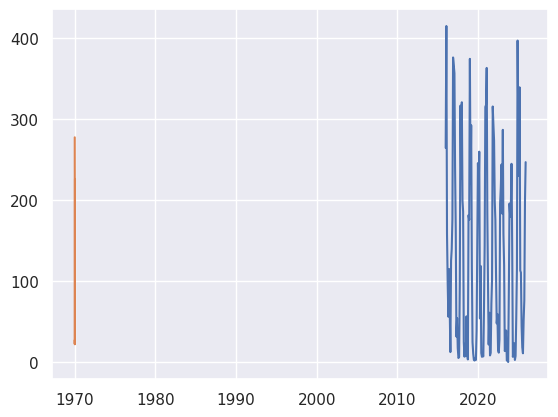

In [47]:
# AMBP BLOK 8

train_block = rain_series['2016-01-01':'2025-12-01']

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_block.values.reshape(-1,1))

X_train, y_train = create_lagged_data(train_scaled, 12)

model = MLPRegressor(hidden_layer_sizes=(10,), activation='relu', solver='adam', max_iter=2000, early_stopping=True, random_state=42)
model.fit(X_train, y_train.ravel())

last = train_scaled[-12:]
forecast_scaled = []
cur = last.copy()

for i in range(12):
    p = model.predict(cur.reshape(1,-1))
    forecast_scaled.append(p[0])
    cur = np.append(cur[1:], p)

forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1,1)).flatten()

print("PREDIKSI 2026")
print(forecast)

plt.plot(train_block)
plt.plot(forecast)
plt.show()